##### import statements

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectPercentile, mutual_info_regression
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB

##### getting the train and test data

In [29]:
# naming the categories and label columns
names = np.array([])
string = "category-"
for i in range(0,54): names = np.append(names, string + str(i))
names = np.append(names, "Labels")

# reading train data
train = pd.read_csv("train.csv", names=names)

# reading test data
names_test = np.delete(names, -1)
test = pd.read_csv("test.csv", names=names_test)

##### oversampling to balance data for labels

In [30]:
def resample(train, sampler):
    train_x = train.iloc[:, :-1].values
    label = train.iloc[:, -1].values
    
    train_x_res, label_res = sampler.fit_resample(train_x, label)

    return train_x_res, label_res

##### scaling

In [31]:
def feature_scaling(train, test):
    # splitting train data into attributes and labels
    train_x = train.iloc[:, :-1].values
    label = train.iloc[:, -1].values

    # getting test data
    test_x = test.iloc[:, :].values

    # performing z-normalization
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(train_x)
    x_test_scaled = scaler.transform(test_x)
    
    return x_train_scaled, x_test_scaled, label

In [32]:
x_train, x_test, label = feature_scaling(train, test)

In [33]:
label_new = np.zeros((label.size, 1))
label_new[:, 0] = label
new_train = np.concatenate((x_train, label_new),axis = 1)
train = pd.DataFrame(new_train)
test = pd.DataFrame(x_test)

##### feature selection

In [34]:
def feature_selection(train, test):
    # Normalizing train and test data to fit a gaussian curve
    train_x, test_x, train_label = feature_scaling(train, test)

    # performing feature selection using SelectPercentile and f_classif as scoring function
    feature_selector = SelectPercentile(mutual_info_regression, percentile=38)
    train_features = feature_selector.fit_transform(train_x, train_label)
    test_features = feature_selector.transform(test_x)

    return train_features, test_features, train_label

In [35]:
train_features, test_features, train_label = feature_selection(train, test)

In [36]:
label_new = np.zeros((train_label.size, 1))
label_new[:, 0] = train_label
new_train = np.concatenate((train_features, label_new),axis = 1)
train = pd.DataFrame(new_train)
test = pd.DataFrame(test_features)

##### Resampling

In [37]:
sampler = SMOTE(random_state=0)
train_x, label = resample(train, sampler)

In [38]:
label_new = np.zeros((label.size, 1))
label_new[:, 0] = label
new_train = np.concatenate((train_x, label_new),axis = 1)
train = pd.DataFrame(new_train)

In [39]:
train.iloc[:, -1].value_counts()

21
2.0    7083
6.0    7083
1.0    7083
7.0    7083
3.0    7083
4.0    7083
5.0    7083
Name: count, dtype: int64

##### K_Nearest_Neigbors Classifier

In [40]:
def KNN(train_features, test_features, labels, k):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(train_features, labels)

    prediction_val = classifier.predict(test_features)
    return classifier, prediction_val

##### Cross-Validation-KNN

In [41]:
k_values = np.arange(1, 25)

accuraciesKNN = []
for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    X = train.iloc[:, :-1]
    y = train.iloc[:, -1]
    cv_results = cross_validate(classifier, X, y, cv=10)
    avg_acc = np.mean(cv_results['test_score'])
    accuraciesKNN.append(avg_acc)

Best 'k' Value:  1
Best Acc:  0.9492748931720136


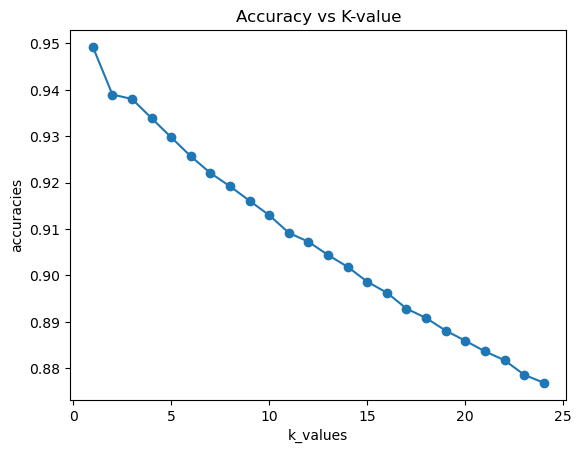

In [42]:
plt.figure()
plt.plot(k_values, accuraciesKNN, marker='o')
plt.xlabel('k_values')
plt.ylabel('accuracies')
plt.title('Accuracy vs K-value')

max_index = accuraciesKNN.index(max(accuraciesKNN))
Best_k_val = k_values[max_index]

print("Best \'k\' Value: ", Best_k_val)
print("Best Acc: ", max(accuraciesKNN))

##### Decision Tree Classifier

In [43]:
def DecisionTree(train_features,test_features,labels,depth):
  clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=depth)
  clf.fit(train_features, labels)
  prediction_values = clf.predict(test_features)
  return clf,prediction_values

##### Cross_Validation_Decision_trees

In [44]:
depth_values = range(10, 40)

accuraciesDT = []
for depth in depth_values:
    X = train.iloc[:, :-1]
    y = train.iloc[:, -1]
    clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=depth)
    avg_acc = np.mean(cross_val_score(clf, X, y, cv=10, scoring='accuracy'))
    accuraciesDT.append(avg_acc)

Best Tree-Depth:  34
Best Acc:  0.9098447243190858


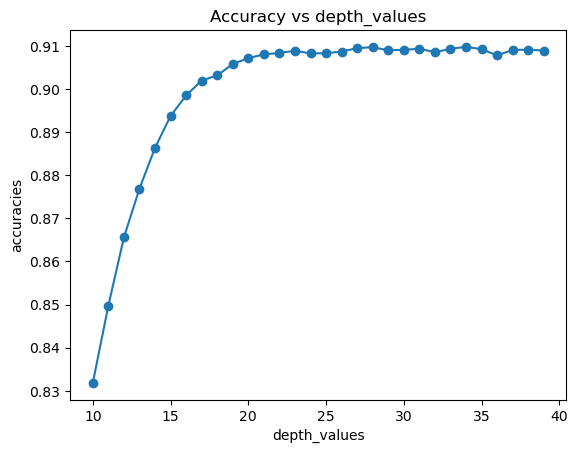

In [45]:
plt.figure()
plt.plot(depth_values, accuraciesDT, marker='o')
plt.xlabel('depth_values')
plt.ylabel('accuracies')
plt.title('Accuracy vs depth_values')

max_index = accuraciesDT.index(max(accuraciesDT))
Best_depth = depth_values[max_index]

print("Best Tree-Depth: ", Best_depth)
print("Best Acc: ", max(accuraciesDT))

##### Naive Bayes Classifier

In [46]:
def NBClassifier(train_features, test_features, labels):
    model = GaussianNB()
    model.fit(train_features, labels)
    prediction_val = model.predict(test_features)
    return classifier, prediction_val

##### Cross_Validation_Naive_Bayes

In [47]:
X = train.iloc[:, :-1]
y = train.iloc[:, -1]
clf = GaussianNB()
avg_acc_NB = np.mean(cross_val_score(clf, X, y, cv=10, scoring='accuracy'))

In [48]:
print("Naive_Bayes_Accuracy: ", avg_acc_NB)

Naive_Bayes_Accuracy:  0.5253422680746136


##### Classifier Comprision through Graphing

Text(0, 0.5, 'Relative Accuracies')

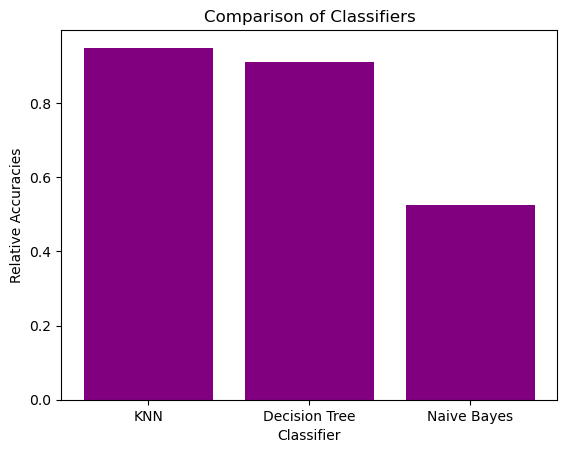

In [49]:
max_knn_accuracy = max(accuraciesKNN)
max_DT_accuracy = max(accuraciesDT)
max_accuracies = [max_knn_accuracy,max_DT_accuracy, avg_acc_NB]
name_of_algorithms = ["KNN", "Decision Tree", "Naive Bayes"]
plt.bar(name_of_algorithms, max_accuracies, color='purple')
plt.title('Comparison of Classifiers')
plt.xlabel('Classifier')
plt.ylabel('Relative Accuracies')

##### Prediction Values For KNN

In [50]:
train_features = train.iloc[:, :-1]
labels = train.iloc[:, -1]
test_features = test.iloc[:, :]
classifier, prediction_val = KNN(train_features, test_features, labels, Best_k_val)

In [51]:
arr_KNN = prediction_val.astype(int)

In [52]:
file_path = "KNN_pred.txt"
with open(file_path, 'w') as file:
    for i in arr_KNN:
        file.write(str(i) + '\n')

##### Prediction Values For Decision tree Classifier

In [53]:
train_features = train.iloc[:, :-1]
labels = train.iloc[:, -1]
test_features = test.iloc[:, :]
classifier, prediction_val = DecisionTree(train_features,test_features,labels,Best_depth)

In [54]:
arr_DT = prediction_val.astype(int)

In [55]:
file_path = "DT_pred.txt"
with open(file_path, 'w') as file:
    for i in arr_DT:
        file.write(str(i) + '\n')

##### Prediction Values For Naive Bayes Classifier

In [56]:
train_features = train.iloc[:, :-1]
labels = train.iloc[:, -1]
test_features = test.iloc[:, :]
classifier, prediction_val = NBClassifier(train_features, test_features, labels)

In [57]:
arr_NB = prediction_val.astype(int)

In [58]:
file_path = "NB_pred.txt"
with open(file_path, 'w') as file:
    for i in arr_NB:
        file.write(str(i) + '\n')